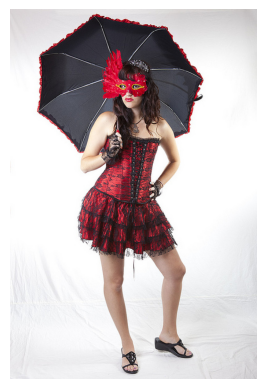

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Load and display an image
image_path =  '/mnt/abka03/mscoco2014/train2014/COCO_train2014_000000334626.jpg' # Replace with your image file path
img = mpimg.imread(image_path)

plt.imshow(img)
plt.axis('off')  # Hide axis for better visualization
plt.show()


In [3]:
from transformers import AutoModelForVision2Seq, AutoProcessor
import torch
import os
os.environ["HF_HOME"] = "/mnt/abka03/huggingface/hub"
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model_name_or_path = "Qwen/Qwen2-VL-7B-Instruct"
processor = AutoProcessor.from_pretrained(model_name_or_path)
model = AutoModelForVision2Seq.from_pretrained(model_name_or_path, torch_dtype=torch.float16,
            low_cpu_mem_usage=True)
model = model.to(device)

/mnt/abka03/.conda/envs/xl_vlm/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-03-20 14:26:40.538192: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1742477200.548587  397340 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1742477200.551786  397340 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-20 14:26:40.563931: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critica

In [6]:
from qwen_vl_utils import process_vision_info

message =  [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image_path},
            {"type": "text", "text": "\n describe the image itmes with one words" },
        ],
    }
]
image_inputs, video_inputs = process_vision_info(message)
texts = processor.apply_chat_template(message, tokenize=False, add_generation_prompt=True)

inputs = processor(
        text=texts,
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    )
inputs = inputs.to("cuda") 

In [7]:
generated_ids = model.generate(**inputs, max_new_tokens=20, do_sample=True,)
generated_ids_trimmed = [
out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
]
output_texts = processor.batch_decode(
    generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
)
print(output_texts)   

['Person, Umbrella, Mask, Dress, Sandals']
